In [132]:
import io, requests, pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, uniform
from sklearn.mixture import GaussianMixture as GM

## Prvi deo

In [133]:
TAP_URL = " https://exoplanetarchive.ipac.caltech.edu/TAP/sync"

query = '''
SELECT
    pl_orbper,
    pl_rade,
    pl_eqt,
    st_met,
    discoverymethod
FROM pscomppars
'''

r = requests.get(TAP_URL, params={"query":query, "format": "csv"},
    timeout =120)
exo = pd.read_csv(io.StringIO(r.text))
exo.head()

,pl_orbper,pl_rade,pl_eqt,st_met,discoverymethod
0,1.003934,1.710000,1419.0,-0.05,Transit
1,8.172400,3.323214,858.0,-0.06,Transit
2,6.283855,0.800000,1108.0,0.07,Transit
3,3.173917,3.150000,1655.0,0.08,Transit
4,56.358501,4.540605,419.0,-0.20,Transit


### Prvi zadatak: udeo vrućih Jupitera

In [134]:
hot_jup = exo[(exo["pl_orbper"] < 10) & (exo["pl_rade"] > 8)]
udeo_hj = len(hot_jup)/len(exo) * 100
print("Udeo vrućih Jupitera u prikupljenom datasetu je ", np.round(udeo_hj, 3), "%")

Udeo vrućih Jupitera u prikupljenom datasetu je  11.766 %


### Drugi zadatak: metaličnost vrućih Jupitera


In [135]:
h_met = exo[exo["st_met"] > 0.4]
hot_jup_h_met = exo[(exo["pl_orbper"] < 10) & (exo["pl_rade"] > 8) & (exo["st_met"] > 0.4)]
udeo_h_met = len(hot_jup_h_met)/len(h_met) * 100
print("Udeo vrućih Jupitera u zvezdama visoke metaličnosti u prikupljenom datasetu je ", np.round(udeo_h_met, 3), "%")

Udeo vrućih Jupitera u zvezdama visoke metaličnosti u prikupljenom datasetu je  36.364 %


Vidimo da je udeo značajno veći u metaličnim zvezdama nego na celom uzorku.

### Treći zadatak: bootstrap metoda

In [136]:
#uzimamo kao uzorak samo podatke za visoku metaličnost
x = np.array(exo.loc[exo["st_met"] > 0.4, "st_met"].dropna())

N = int(1e5) #broj realizacija uzorkovanja
mean = np.zeros(N)
std = np.zeros(N)
n = len(x)

for i in range(N):
    uzorak = np.random.choice(x, size=n, replace=True)
    mean[i] = np.mean(uzorak)
    std[i] = np.std(uzorak, ddof=1)


In [137]:
#vrednosti uzorka
x_mean = np.mean(x)
x_std = np.std(x, ddof=1)

#analitičke vrednosti
an_mean = x_std/np.sqrt(n)
an_std = x_std/np.sqrt(2*(n-1))

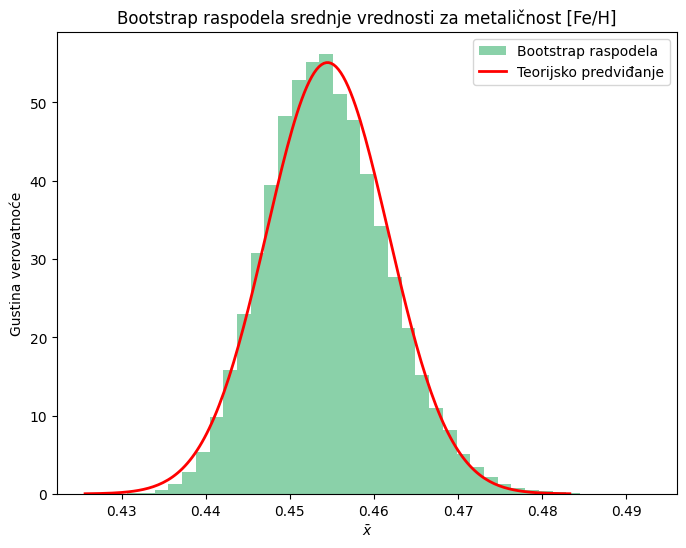

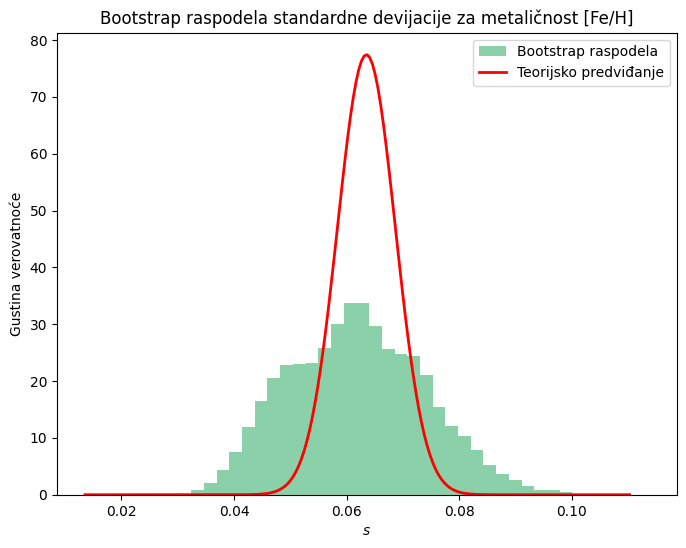

In [138]:
#plotovanje
fig, ax = plt.subplots(figsize=(8, 6))

ax.hist(
    mean,
    bins=40,
    density=True,
    alpha=0.6,
    color='mediumseagreen',
    label='Bootstrap raspodela'
)

mean_boot = np.mean(mean)
std_boot = np.std(mean)

grid = np.linspace(
    mean_boot - 4 * std_boot,
    mean_boot + 4 * std_boot,
    200
)

teorijska = norm.pdf(grid, loc=x_mean, scale=an_mean)

ax.plot(
    grid,
    teorijska,
    color='red',
    lw=2,
    label='Teorijsko predviđanje'
)

ax.set_xlabel(r'$\bar{x}$')
ax.set_ylabel('Gustina verovatnoće')
ax.set_title('Bootstrap raspodela srednje vrednosti za metaličnost [Fe/H]')
ax.legend()

plt.show()


fig, ax = plt.subplots(figsize=(8, 6))

ax.hist(
    std,
    bins=40,
    density=True,
    alpha=0.6,
    color='mediumseagreen',
    label='Bootstrap raspodela'
)

mean_std_boot = np.mean(std)
spread_std_boot = np.std(std)

grid = np.linspace(
    mean_std_boot - 4 * spread_std_boot,
    mean_std_boot + 4 * spread_std_boot,
    200
)

teorijska2 = norm.pdf(grid, loc=x_std, scale=an_std)

ax.plot(
    grid,
    teorijska2,
    color='red',
    lw=2,
    label='Teorijsko predviđanje'
)

ax.set_xlabel(r'$s$')
ax.set_ylabel('Gustina verovatnoće')
ax.set_title('Bootstrap raspodela standardne devijacije za metaličnost [Fe/H]')
ax.legend()

plt.show()

Vidimo da je pretpostavka normalnosti opravdanija za raspodelu srednje vrednosti nego za raspodelu standardne devijacije. Jackknife metoda ne bi dala bolje rezultate za standardnu devijaciju jer nije odgovarajuća za nelinearne statistike.

## Drugi deo

3 GaussianMixture(n_components=np.int64(3))


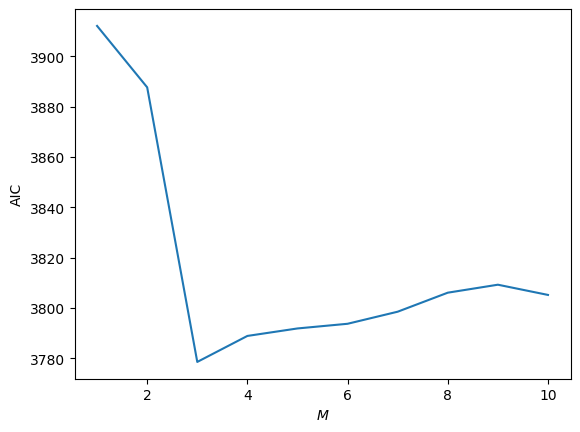

In [139]:
rs = np.random.RandomState(seed=1)

X = np.concatenate([rs.normal(-1,1.5,350),
                    rs.normal(0, 1, 500),
                    rs.normal(3, 0.5,150)]).reshape(-1, 1)

N = np.arange(1, 11)
modeli = [None for i in range(len(N))]

for i in range(len(N)):
    modeli[i]=GM(N[i]).fit(X)

AIC = [m.aic(X) for m in modeli]
najbolje_N = N[np.argmin(AIC)]
najbolji_model = modeli[np.argmin(AIC)]
print(najbolje_N, najbolji_model)

plt.plot(N, AIC)
plt.xlabel('$M$')
plt.ylabel('AIC')
plt.show( )

Ovo je dato u zadatku, kao nalaženje AIC za mešavinu 3 normalne raspodele. Naš zadatak je da nađemo optimalan broj komponenti M za raspodelu Rp koristeći AIC i GMM.

### Četvrti zadatak: fitovanje raspodele

In [140]:
Rp = exo['pl_rade'].dropna()
Rp = Rp.values.reshape(-1,1)
logRp = np.log10(Rp)

In [154]:
#isti postupak kao što je dato u zadatku
N = np.arange(1, 11)
modeli = [None for i in range(len(N))]

for i in range(len(N)):
    modeli[i] = GM(N[i]).fit(logRp)

AIC = [m.aic(logRp) for m in modeli]

najbolje_N = N[np.argmin(AIC)]
najbolji_model = modeli[np.argmin(AIC)]

print("Optimalan broj komponenti M je", najbolje_N)
najbolji_model = GM(n_components=najbolje_N, random_state=67).fit(logRp) #fitovanje modela

Optimalan broj komponenti M je 7


In [155]:
x = np.linspace(logRp.min(), logRp.max(), 1000).reshape(-1, 1) #x osa za grafički prikaz fita
lograsp = najbolji_model.score_samples(x) #fitovanje raspodele
pdf = np.exp(lograsp)

pdf_pojed = najbolji_model.predict_proba(x) * pdf[:, np.newaxis] #računanje pojedinačnih komponenti

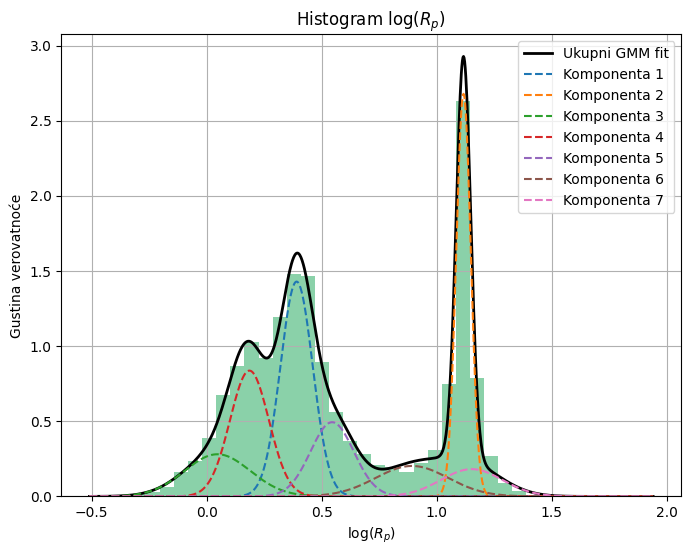

In [156]:
#plotovanje
fig, ax = plt.subplots(figsize=(8, 6))

ax.hist(
    logRp,
    bins=40,
    density=True,
    alpha=0.6,
    color='mediumseagreen'
)

ax.plot(
    x,
    pdf,
    color='black',
    linewidth=2,
    label='Ukupni GMM fit'
)

for i in range(najbolje_N):
    komponenta = pdf_pojed[:, i]
    ax.plot(
        x,
        komponenta,
        linestyle='--',
        linewidth=1.5,
        label=f'Komponenta {i+1}'
    )

ax.set_title(r'Histogram $\log(R_p)$')
ax.set_xlabel(r'$\log(R_p)$')
ax.set_ylabel('Gustina verovatnoće')
ax.legend()
ax.grid(True)

plt.show()


Ponavljamo identičan postupak za deo uzorka planeta otkrivenih metodom tranzita

In [144]:
Rpt = exo[exo['discoverymethod'] == 'Transit']
Rpt = Rpt['pl_rade'].dropna()
Rpt = Rpt.values.reshape(-1,1)
logRpt = np.log10(Rpt)

In [145]:
#isti postupak kao što je dato u zadatku
N = np.arange(1, 11)
modeli = [None for i in range(len(N))]

for i in range(len(N)):
    modeli[i] = GM(N[i]).fit(logRpt)

AIC = [m.aic(logRpt) for m in modeli]

najbolje_N = N[np.argmin(AIC)]
najbolji_model = modeli[np.argmin(AIC)]

print("Optimalan broj komponenti M je", najbolje_N)
najbolji_model = GM(n_components=najbolje_N, random_state=67).fit(logRpt) #fitovanje modela

Optimalan broj komponenti M je 6


In [146]:
xt = np.linspace(logRpt.min(), logRpt.max(), 1000).reshape(-1, 1) #x osa za grafički prikaz fita
lograspt = najbolji_model.score_samples(xt) #fitovanje raspodele
pdft = np.exp(lograspt)

pdft_pojed = najbolji_model.predict_proba(xt) * pdft[:, np.newaxis] #računanje pojedinačnih komponenti

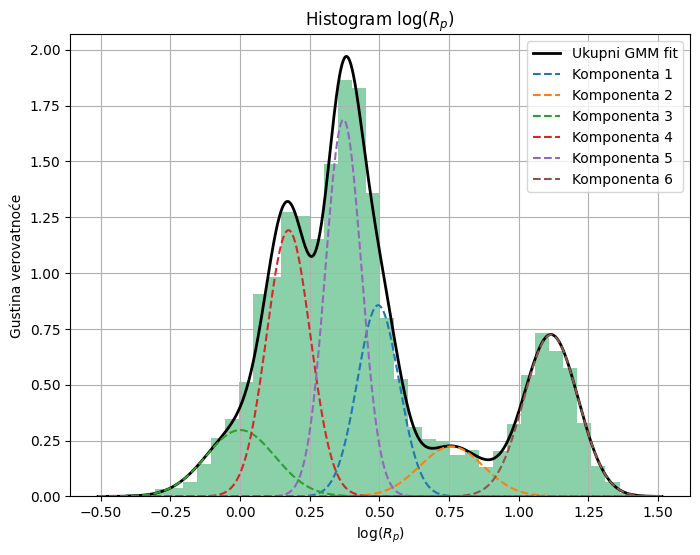

In [147]:
#plotovanje
fig, ax = plt.subplots(figsize=(8, 6))

ax.hist(
    logRpt,
    bins=40,
    density=True,
    alpha=0.6,
    color='mediumseagreen'
)

ax.plot(
    xt,
    pdft,
    color='black',
    linewidth=2,
    label='Ukupni GMM fit'
)

for i in range(najbolje_N):
    komponentat = pdft_pojed[:, i]
    ax.plot(
        xt,
        komponentat,
        linestyle='--',
        linewidth=1.5,
        label=f'Komponenta {i+1}'
    )

ax.set_title(r'Histogram $\log(R_p)$')
ax.set_xlabel(r'$\log(R_p)$')
ax.set_ylabel('Gustina verovatnoće')
ax.legend()
ax.grid(True)

plt.show()

Kada raspodelu radijusa predstavimo na log-skali, jasno se uočava "rupa" u raspodeli na oko $\log10(R_p) = 0.75$. Ovo se može tumačiti kao posledica postojanja dve diskretne populacije egzoplaneta: stenovitih, sličnih Zemlji, i gasovitih, sličnih spoljnim planetama Sunčevog sistema. Ove dve populacije različito nastaju i druga populacija je generalno značajno veća (većih radijusa) od prve, zbog čega uočavamo manjak planeta u radijusima vrednosti između onih tipičnih za prvu i drugu populaciju.

## Treći deo

### Peti zadatak: nalaženje planete sa $T_{eq}$ najbližim Zemlji

In [148]:
Teq_z = 255 #Teq Zemlje u kelvinima

exoteq = exo.dropna(subset=['pl_eqt']) #samo planete za koje se zna Teq
indmin = np.abs((exoteq["pl_eqt"] - Teq_z)).idxmin() #indeks planete sa najmanjom razlikom Teq od Zemljine
pl = exoteq.loc[indmin]
Teq_pl = pl['pl_eqt']

In [149]:
#uzimanje traženih podataka queryem
query = f"""
SELECT
    pl_name,
    hostname,
    sy_pnum,
    sy_snum,
    pl_bmasse,
    pl_orbeccen,
    discoverymethod,
    pl_eqt,
    disc_telescope
FROM pscomppars
WHERE pl_eqt = '{Teq_pl}'
"""

r = requests.get(TAP_URL, params={"query":query, "format": "csv"},
    timeout =120)
pl_data = pd.read_csv(io.StringIO(r.text))

print('Broj zvezda je:', pl_data["sy_snum"].values)
print('Broj planeta je:', pl_data["sy_pnum"].values)
print('Metoda otkrića je:', pl_data["discoverymethod"].values)
print('Masa planete je:', pl_data["pl_bmasse"].values)
print('Ekscentricitet je:', pl_data["pl_orbeccen"].values)
print('Teleskop kojim je snimano je:', pl_data["disc_telescope"].values)

Broj zvezda je: [1]
Broj planeta je: [5]
Metoda otkrića je: ['Radial Velocity']
Masa planete je: [7.1]
Ekscentricitet je: [0.29]
Teleskop kojim je snimano je: ['3.6 m ESO Telescope']


### Šesti zadatak: ECDF

In [150]:
teq = np.sort(exo['pl_eqt'].dropna().values)
ecdf = np.arange(1, len(teq)+1)/len(teq) #pravljenje ECDFa - ovako mi iz nekog razloga bolje prolazi nego np.linspace za pravljenje niza od 0 do 1, nisam stigao da shvatim zašto

In [151]:
#inverzno semplovanje
Nsemp = int(1e3)
u = np.random.uniform(0, 1, Nsemp)
teq_sint = np.interp(u, ecdf, teq) #inverzna interpolacija

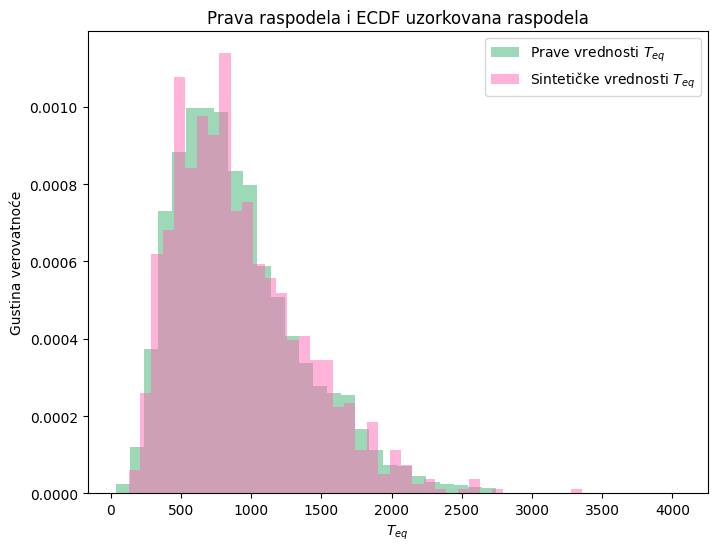

In [152]:
#plotovanje
fig, ax = plt.subplots(figsize=(8, 6))

ax.hist(
    teq,
    bins=40,
    density=True,
    alpha=0.5,
    color='mediumseagreen',
    label=r'Prave vrednosti $T_{eq}$'
)

ax.hist(
    teq_sint,
    bins=40,
    density=True,
    alpha=0.5,
    color='hotpink',
    label=r'Sintetičke vrednosti $T_{eq}$'
)

ax.set_title('Prava raspodela i ECDF uzorkovana raspodela')
ax.set_xlabel(r'$T_{eq}$')
ax.set_ylabel('Gustina verovatnoće')

ax.legend()

plt.show()

Vidimo da se sintetička i prava raspodela dosta dobro slažu na histogramu.

Ova metoda (inverse sampling) se suštinski razlikuje od bootstrap metode po tome što se u bootstrap metodi nasumično izvlače podaci sa vraćanjem iz tog istog uzorka, to jest ne stvaraju se nove vrednosti koje nisu postojale u originalnom uzorku, dok u inverse samplingu želimo da generišemo nove podatke koji imaju istu raspodelu kao originalni uzorak, to jest reprodukuje celu raspodelu ali stvara nove realizacije slučajne promenljive i samim tim nove vrednosti u uzorku.

Za fitovanje raspodele $T_{eq}$ ne bismo mogli da koristimo običnu normalnu raspodelu zbog asimetričnosti podataka, tj dugog repa sa desne strane koji ne postoji sa leve. Jedno rešenje za ovo bi bilo korišćenje na primer gama raspodele, koja opisuje strogo pozitivne vrednosti sa asimetričnim peakom koji ima duži rep sa desne strane, što u prvoj aproksimaciji opisuje naše podatke.